In [134]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score



In [135]:
df = pd.read_csv("student_exam_data.csv")
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [136]:
df.shape

(500, 3)

In [137]:
df.columns

Index(['Study Hours', 'Previous Exam Score', 'Pass/Fail'], dtype='object')

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [139]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


In [140]:
df.isnull().sum()

Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

In [141]:
X = df[["Study Hours", "Previous Exam Score"]]
y = df["Pass/Fail"]

print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [143]:
model = LogisticRegression()

In [144]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [145]:
y_pred = model.predict(X_test)

In [146]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "predicted": y_pred
})
comparison.head()

,Actual,predicted
0,1,0
1,1,1
2,0,0
3,0,0
4,0,0


In [147]:
accuracy = accuracy_score(y_test,y_pred)

print ("Accuracy:", accuracy)


Accuracy: 0.86


In [148]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[58  6]
 [ 8 28]]


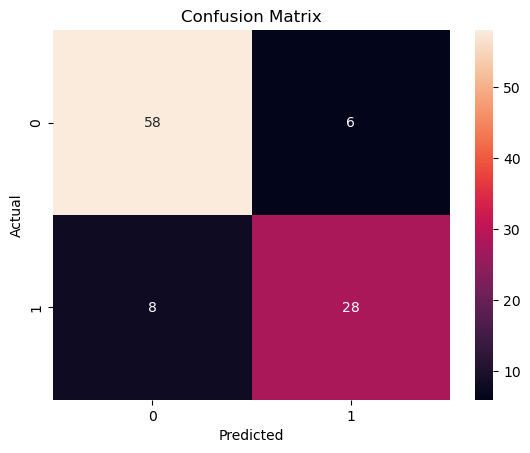

In [149]:
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [150]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8235294117647058


In [151]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7777777777777778


In [152]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8


In [153]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.86
Precision: 0.8235294117647058
Recall   : 0.7777777777777778
F1 Score : 0.8


In [154]:
print("Intercept:",model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [-18.77322498]
Coefficient: [[1.19008645 0.15256702]]


## Manual Prediction

In [155]:
new_student = pd.DataFrame({
    "Study Hours": [5],
    "Previous Exam Score": [70]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Result: Pass")
else:
    print("Result: Fail")

Result: Fail


## Model Limitations

The Logistic Regression model achieved good performance on the test data, but it has some limitations.

- The model uses only Study Hours and Previous Exam Score.
- Other factors such as Attendance, Sleep, Motivation, and Study Environment may also affect student performance.
- The model's predictions are based on the patterns present in the given dataset.
- A prediction of Pass or Fail is not a guaranteed real-world result.

## Conclusion

In this project, I built a Logistic Regression model to predict whether a student will Pass or Fail based on Study Hours and Previous Exam Score.

The dataset was divided into training and testing sets, and the Logistic Regression model was trained using the training data.

The model achieved an accuracy of 86%. I also evaluated the model using Precision, Recall, F1-Score, and a Confusion Matrix.

The Confusion Matrix helped me understand the correct and incorrect Pass/Fail predictions using True Positive, True Negative, False Positive, and False Negative values.

Overall, this project helped me understand the basic workflow of Logistic Regression for binary classification, from data preparation and model training to prediction and model evaluation.